# ForestWatch Papua — Training **MODEL: Attention U-Net (SCSE)**

**Jalankan di KOMPUTER 1.** Arsitektur: `unet_scse` + `resnet50` (ImageNet). Resep training (loss, class weights, weighted sampler, AMP, freeze-encoder warmup, cosine LR) **identik** dengan ke-2 model lain → perbandingan apple-to-apple.

Output ditulis ke **folder khusus model ini** di gdrive: `ForestWatch_Outputs/Model_Comparison/model_1_attention_unet/` (checkpoint, kurva, metrics, confusion, ONNX, summary) → 3 mesin paralel **tidak saling timpa**.

Setelah ke-3 model selesai, jalankan `compare_and_select_best_model.ipynb`.

## Bagian 0 — Setup environment (Colab **/** Lab **/** Jetson)

Notebook ini **berdiri sendiri**. Ia **memuat hasil EDA & preprocessing**
(Bagian 1–14 dari `forestwatch_papua_full_pipeline.ipynb`) yang sudah tersimpan
di Google Drive — **tidak menghitung ulang**.

- **Google Colab** → set `ENV = "colab"`. Sel setup meng-clone repo, install
  package, lalu mount Drive. (Dipakai hanya untuk bundling `.tar` ke Drive.)
- **Komputer lab** → set `ENV = "lab"`. Prasyarat **sekali saja**:
  1. Install **Google Drive for Desktop**, login akun yang sama, set folder
     `Satria Data 3.0` ke mode **Mirror** (bukan *Stream-only*) supaya file `.npz`
     benar-benar ada di disk lokal (DataLoader membaca ribuan file tiap epoch).
  2. Di clone repo lokal jalankan: `pip install -e ".[ml]"`.
  3. Sesuaikan `DRIVE_ROOT` ke path mount Drive Desktop (mis. `G:/My Drive/Satria Data 3.0`).
- **Jetson Orin** (JetPack 5.x, Python 3.8, torch 2.1) → set `ENV = "jetson"`.
  Arsitektur **PC = storage, Jetson = compute** (dataset di-mount via SMB).
  Prasyarat **sekali saja**:
  1. Di PC: share folder hasil ekstrak `Bahan_Training_Model/` (berisi `train/`,
     `val/`, `test/`, `class_weights.json`, `patch_sampler_weights_shared.json`)
     via SMB. Di Jetson mount, mis.:
     `sudo mount -t cifs //IP_PC/Dataset_Satria /mnt/forestwatch_dataset -o user=USER,uid=$(id -u),gid=$(id -g)`.
  2. Pastikan torch JetPack ada (**JANGAN** reinstall via pip):
     `python -c "import torch; print(torch.__version__, torch.cuda.is_available())"` → `2.1.x True`.
  3. Di clone repo lokal jalankan: `pip install -e ".[jetson]"` (deps ML non-torch).
  4. Sesuaikan `DATA_ROOT` ke path mount SMB (mis. `/mnt/forestwatch_dataset`).

## ALTERNATIF CEPAT — Evaluasi saja (skip training ulang)

Kalau training sudah selesai (`best_model.pt` + `best_model_resume.pt` sudah ada) dan kamu HANYA mau menjalankan evaluasi/plot/ekspor (cell 12-14), jalankan cell di bawah ini **SEBAGAI GANTI** cell 2-3-4-5-7-9-10-11, lalu lompat langsung ke cell 12.

Mendukung **Colab** (baca dari Drive, auto-deteksi) atau **Kaggle** (lebih disarankan kalau Colab kehabisan RAM saat eval) -- auto-deteksi via folder `/kaggle`. Untuk Kaggle: upload `best_model.pt` + `best_model_resume.pt` jadi dataset baru (mis. `model1-checkpoint`), lalu **Add Input** dataset itu + `fw-papua-valtest` (sudah ada dari training sebelumnya) sebelum jalankan cell ini.

Kalau mau training dari awal/resume seperti biasa, **SKIP cell ini**, lanjut normal ke cell 2.

In [1]:
# === FAST PATH: evaluasi tanpa training ulang (Colab GDrive / Kaggle) ===
import os, sys, subprocess, importlib
from pathlib import Path
import torch
from torch.utils.data import DataLoader

ENV = "kaggle" if Path("/kaggle").exists() else "colab"
print(f"[fast-path] ENV terdeteksi: {ENV}")

if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run(
        "cd /content && (git -C fw_repo pull -q || git clone --depth 1 "
        "https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo)",
        shell=True, check=False,
    )
    subprocess.run("pip install -q -e /content/fw_repo[ml]", shell=True, check=False)
    REPO_SRC = "/content/fw_repo/src"
else:
    subprocess.run(
        "cd /kaggle/working && (git -C fw_repo pull -q || git clone --depth 1 "
        "https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo)",
        shell=True, check=False,
    )
    subprocess.run("pip install -q --no-deps -e /kaggle/working/fw_repo[ml]", shell=True, check=False)
    subprocess.run("pip install -q --no-deps segmentation-models-pytorch albumentations torchmetrics",
                   shell=True, check=False)
    REPO_SRC = "/kaggle/working/fw_repo/src"

if REPO_SRC not in sys.path:
    sys.path.insert(0, REPO_SRC)
for _m in [m for m in list(sys.modules) if m == "forestwatch" or m.startswith("forestwatch.")]:
    del sys.modules[_m]
importlib.invalidate_caches()

from forestwatch.config import load_config
from forestwatch.utils.io import save_json
from forestwatch.constants import N_CLASSES, CLASS_NAMES, CLASS_COLORS
from forestwatch.model.architecture import build_unet, count_parameters
from forestwatch.data.dataset import extract_dataset_archives, PapuaDataset
from forestwatch.data.patches import list_patches

cfg = load_config()
MODEL_KEY  = "model_1_attention_unet"
MODEL_ARCH = dict(architecture="unet_scse", encoder_name="resnet50")

if ENV == "colab":
    DRIVE_ROOT = Path("/content/drive/MyDrive/Satria Data 3.0")
    BAHAN_DIR  = DRIVE_ROOT / 'Bahan_Training_Fix'
    MODEL_DIR  = DRIVE_ROOT / 'ForestWatch_Outputs' / 'Model_Comparison' / MODEL_KEY
    CKPT_PATH  = MODEL_DIR / 'best_model.pt'
    RESUME_PATH = MODEL_DIR / 'best_model_resume.pt'
    LOCAL_DIR = Path('/content/dataset_local')
    local_dirs = extract_dataset_archives(BAHAN_DIR, LOCAL_DIR, splits=('test',), max_workers=4)
    test_dir = local_dirs['test']
else:
    # Kaggle: attach dataset "model1-checkpoint" (best_model.pt + best_model_resume.pt)
    # dan "fw-papua-valtest" (utk folder test/) lewat Add Input sebelum jalankan cell ini.
    MODEL_DIR = Path("/kaggle/working/Model_Comparison") / MODEL_KEY
    CKPT_PATH = next(Path("/kaggle/input").rglob("best_model.pt"))
    RESUME_PATH = next(Path("/kaggle/input").rglob("best_model_resume.pt"))
    test_dir = next(Path("/kaggle/input").rglob("test"))

OUTPUT_DIR = MODEL_DIR / 'output'; OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

state = torch.load(RESUME_PATH, map_location='cpu')
hist = state['history']
summary = {'best_val_iou': state['best_iou'], 'best_epoch': state['best_epoch'], 'history': hist,
           'ckpt_path': str(CKPT_PATH), 'resume_path': str(RESUME_PATH)}
train_minutes = round(sum(h.get('epoch_time_sec', 0) for h in hist) / 60, 1)
print(f"Riwayat dimuat: {len(hist)} epoch | best mIoU={summary['best_val_iou']:.4f} @ epoch {summary['best_epoch']}")

# num_workers=0 (TANPA multiprocessing DataLoader) -- terbukti empiris: kombinasi
# num_workers>0 + pin_memory=True memicu RAM bocor s/d puluhan GB di lingkungan ini
# (test dgn loop manual tanpa DataLoader: RAM stabil). Evaluasi cuma 1x pass, GPU
# yg jadi bottleneck bukan I/O, jadi tak rugi kehilangan paralelisme loading.
test_p = list_patches(test_dir)
test_loader = DataLoader(PapuaDataset(test_p, train=False),
                          batch_size=cfg['training']['batch_size'], num_workers=0,
                          pin_memory=False, shuffle=False)
print(f"Test patches: {len(test_p)}")

model = build_unet(in_channels=cfg['model']['in_channels'], classes=cfg['model']['classes'],
                    encoder_weights=cfg['model']['encoder_weights'], **MODEL_ARCH)
print(f"{MODEL_KEY}: {count_parameters(model):,} param | CUDA={torch.cuda.is_available()}")
print("Selesai -- lanjut ke cell 15 (lewati cell 2-14, evaluasi langsung tanpa DataLoader).")

[fast-path] ENV terdeteksi: colab
Mounted at /content/drive


Extract test_part01.tar:   0%|          | 0/19346 [00:00<?, ?file/s]

Riwayat dimuat: 55 epoch | best mIoU=0.4805 @ epoch 42
Test patches: 19346


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model_1_attention_unet: 33,826,354 param | CUDA=True
Selesai -- lanjut ke cell 12 (lewati cell 2-11).


In [ ]:
# === Bagian 0 — Setup (set ENV = "colab" / "lab" / "jetson") ===
ENV = "colab"   # "colab" | "lab" (PC+Drive Desktop) | "jetson" (Orin+SMB) | "kaggle" (Kaggle+dataset)
from pathlib import Path

# Auto-deteksi Kaggle: override ENV meski lupa ganti dari default di atas
# (folder /kaggle hanya ada di runtime Kaggle, tak pernah ada di Colab/lab/Jetson).
if Path("/kaggle").exists() and ENV != "kaggle":
    print(f"[auto-detect] /kaggle terdeteksi, override ENV='{ENV}' -> 'kaggle'")
    ENV = "kaggle"

DRIVE_ROOT = None     # diisi utk colab/lab
DATA_ROOT = None      # diisi utk jetson (mount SMB dari PC)
OUTPUTS_ROOT = None   # diisi utk jetson (output ke disk lokal Jetson)

if ENV == "colab":
    import subprocess, sys, importlib
    # clone pertama kali / pull sesi berikutnya (selalu kode terbaru), lalu install.
    subprocess.run(
        "cd /content && (git -C fw_repo pull -q || git clone --depth 1 "
        "https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo)",
        shell=True, check=False,
    )
    subprocess.run("pip install -q -e /content/fw_repo[gee,gis,ml]", shell=True, check=False)
    if "/content/fw_repo/src" not in sys.path:
        sys.path.insert(0, "/content/fw_repo/src")
    for _m in [m for m in list(sys.modules) if m == "forestwatch" or m.startswith("forestwatch.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/Satria Data 3.0")
    assert DRIVE_ROOT.exists(), f"DRIVE_ROOT {DRIVE_ROOT} tidak ada — cek mount Drive."
elif ENV == "lab":
    DRIVE_ROOT = Path(r"G:/My Drive/Satria Data 3.0")   # <- SESUAIKAN path mount Drive Desktop lab
    assert DRIVE_ROOT.exists(), (
        f"DRIVE_ROOT {DRIVE_ROOT} tidak ada — cek mount Drive / sync (mode Mirror)."
    )
elif ENV == "jetson":
    # JetPack 5.x / Python 3.8 / torch 2.1 (dari JetPack -- JANGAN reinstall torch via pip).
    # Dataset hasil ekstrak di-mount via SMB dari PC (cifs). EDIT path mount di bawah.
    DATA_ROOT = Path("/mnt/forestwatch_dataset")        # <- folder 'Bahan_Training_Model' yg di-mount (train/val/test + json)
    OUTPUTS_ROOT = Path.home() / "forestwatch_outputs"  # output lokal Jetson (cepat); salin ke PC utk notebook banding
    assert DATA_ROOT.exists(), (
        f"DATA_ROOT {DATA_ROOT} tidak ada — mount SMB share dari PC dulu (mount -t cifs ...)."
    )
elif ENV == "kaggle":
    # Kaggle Notebook (GPU). Internet HARUS ON (Settings -> Internet) utk clone+install.
    import subprocess, sys, importlib, os, shutil
    subprocess.run(
        "cd /kaggle/working && (git -C fw_repo pull -q || git clone --depth 1 "
        "https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo)",
        shell=True, check=False,
    )
    # --no-deps: skip resolve dependency penuh thd stack RAPIDS bawaan Kaggle (cuml/cudf/
    # dask-cuda dll, tak kita pakai) -- itu yg bikin pip lama + wall-of-text konflik palsu.
    subprocess.run("pip install -q --no-deps -e /kaggle/working/fw_repo[ml]", shell=True, check=False)
    subprocess.run("pip install -q --no-deps segmentation-models-pytorch albumentations torchmetrics",
                   shell=True, check=False)
    if "/kaggle/working/fw_repo/src" not in sys.path:
        sys.path.insert(0, "/kaggle/working/fw_repo/src")
    for _m in [m for m in list(sys.modules) if m == "forestwatch" or m.startswith("forestwatch.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()

    from forestwatch.data.dataset import extract_dataset_archives

    BAHAN_SRC = Path("/kaggle/temp/bahan_src")
    BAHAN_SRC.mkdir(parents=True, exist_ok=True)

    # rglob (bukan iterdir 1-level) -- robust thd struktur mount /kaggle/input/<slug>/...
    # yang nesting-nya bisa beda2 tergantung cara Kaggle unpack dataset --dir-mode tar.
    target_names = ["train", "val", "test", "train_rajaampat",
                     "class_weights.json", "patch_sampler_weights_shared.json"]
    for _target in target_names:
        _found = list(Path("/kaggle/input").rglob(_target))
        if _found:
            _link = BAHAN_SRC / _target
            if not _link.exists():
                os.symlink(_found[0], _link)

    _splits = tuple(s for s in ("train", "val", "test", "train_rajaampat") if (BAHAN_SRC / s).exists())
    assert {"train", "val", "test"}.issubset(_splits), (
        f"train/val/test tak lengkap di /kaggle/input (ketemu: {_splits}). Cek attach dataset."
    )

    # Deteksi: kalau Kaggle sudah unpack jadi folder -> pakai langsung (tanpa extract_dataset_archives).
    # Kalau masih arsip .tar -> ekstrak spt biasa.
    if (BAHAN_SRC / "train").is_dir():
        DATA_ROOT = BAHAN_SRC
    else:
        DATA_ROOT = Path("/kaggle/temp/dataset_local")
        extract_dataset_archives(BAHAN_SRC, DATA_ROOT, splits=_splits, max_workers=8)
        for _j in ("class_weights.json", "patch_sampler_weights_shared.json"):
            if (BAHAN_SRC / _j).exists() and not (DATA_ROOT / _j).exists():
                shutil.copy(BAHAN_SRC / _j, DATA_ROOT / _j)

    OUTPUTS_ROOT = Path("/kaggle/working")
else:
    raise ValueError("ENV harus 'colab', 'lab', 'jetson', atau 'kaggle'")

import torch
_root = DATA_ROOT if ENV in ("jetson", "kaggle") else DRIVE_ROOT
_gpu = f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""
print(f"ENV={ENV} | ROOT={_root} | CUDA={torch.cuda.is_available()}{_gpu}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ENV=colab | ROOT=/content/drive/MyDrive/Satria Data 3.0 | CUDA=False


In [ ]:
# === Deklarasi path (hasil EDA & preprocessing) + load config ===
from forestwatch.config import load_config
from forestwatch.utils.io import save_json, load_json
cfg = load_config()

if ENV in ("jetson", "kaggle"):
    # Jetson: tak ada Drive. Data dari mount SMB (cell 4); output ke disk lokal Jetson.
    OUT_DIR     = OUTPUTS_ROOT
    MASK_DIR    = OUTPUTS_ROOT / 'ForestWatch_Masks'
    MODELS_ROOT = OUTPUTS_ROOT / 'Model_Comparison'
else:
    TILES_T1   = DRIVE_ROOT / 'ForestWatch_Tiles_T1'
    TILES_T2   = DRIVE_ROOT / 'ForestWatch_Tiles_T2'
    PATCH_DIR  = DRIVE_ROOT / 'ForestWatch_Patches'           # patch Papua (+ ckpt kanonik)
    PATCHES_TRANSFER  = DRIVE_ROOT / 'ForestWatch_Patches_Transfer'
    AUGMENTED_PATCHES = DRIVE_ROOT / 'Augmented_Patches'
    DIST_DIR   = DRIVE_ROOT / 'Distribution_Reports'
    MASK_DIR   = DRIVE_ROOT / 'ForestWatch_Masks'
    OUT_DIR    = DRIVE_ROOT / 'ForestWatch_Outputs'
    MODELS_ROOT = OUT_DIR / 'Model_Comparison'                # folder induk 3 model

MODELS_ROOT.mkdir(parents=True, exist_ok=True)
print('Resep training :', cfg['training']['loss']['type'],
      '| epochs:', cfg['training']['epochs'], '| batch:', cfg['training']['batch_size'])
print('MODELS_ROOT    :', MODELS_ROOT)

Resep training : focal_tversky | epochs: 80 | batch: 8
MODELS_ROOT    : /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison


In [ ]:
# === Muat hasil PREPROCESSING (deklarasi + panggil; BUKAN hitung ulang) ===
import json
from forestwatch.constants import N_CLASSES, CLASS_NAMES
from forestwatch.data import build_dataloaders_from_files, list_patches, split_files
from forestwatch.training.metrics import median_frequency_weights

if ENV in ("jetson", "kaggle"):
    # Dataset SUDAH diekstrak di PC (train/val/test + class_weights.json) & di-mount SMB.
    # Tak perlu split ulang (sudah materialized jadi folder) atau akses Drive.
    BAHAN_DIR = DATA_ROOT
    final_train_files = list_patches(BAHAN_DIR / 'train')
    _ra_local = list_patches(BAHAN_DIR / 'train_rajaampat')   # tar terpisah (Gag); [] bila tak ada
    if _ra_local:
        final_train_files = final_train_files + _ra_local
        print(f'  + {len(_ra_local)} patch Raja Ampat (Tambang asli, tar terpisah)')
    val_p  = list_patches(BAHAN_DIR / 'val')
    test_p = list_patches(BAHAN_DIR / 'test')
    assert final_train_files and val_p and test_p, (
        f"train/val/test kosong di {BAHAN_DIR} — cek mount SMB & hasil ekstraksi di PC."
    )
    class_weights = load_json(BAHAN_DIR / 'class_weights.json')['class_weights']
    print(f"[jetson] train={len(final_train_files)} val={len(val_p)} test={len(test_p)} <- {BAHAN_DIR}")
    print('class_weights (dari PC):', [round(float(w), 3) for w in class_weights])
else:
    # Split sumber-aware IDENTIK Bagian 14.1 (seed=42): val/test = Papua-only holdout;
    # transfer + augmentasi offline -> train. Class weights dari distribusi Bagian 14.3.
    papua_files    = list_patches(PATCH_DIR)
    transfer_files = list_patches(PATCHES_TRANSFER)
    aug_files      = list_patches(AUGMENTED_PATCHES)
    assert papua_files, (
        f"Tidak ada patch di {PATCH_DIR}. Pastikan Bagian 1-14 (notebook utama) sudah "
        "dijalankan & Google Drive sudah selesai sync."
    )

    train_p, val_p, test_p = split_files(papua_files, train_ratio=0.8, val_ratio=0.1, seed=42)
    final_train_files = list(train_p) + list(transfer_files) + list(aug_files)
    print(f"train={len(final_train_files)} (papua={len(train_p)}+transfer={len(transfer_files)}"
          f"+aug={len(aug_files)}), val={len(val_p)}, test={len(test_p)} (Papua holdout)")

    _post_aug = DIST_DIR / 'distribution_post_augmentation_on_target.json'
    assert _post_aug.exists(), (
        f"{_post_aug} belum ada — jalankan Bagian 14.3 di notebook utama dulu "
        "(recompute distribusi TRAIN FINAL + median-frequency weights)."
    )
    dist_final = {int(k): int(v) for k, v in json.load(open(_post_aug))['counts'].items()}
    class_weights = median_frequency_weights(dist_final, n_classes=N_CLASSES)
    print('class_weights (median-freq):', [round(float(w), 3) for w in class_weights])

train=173078 (papua=154762+transfer=14292+aug=4024), val=19345, test=19346 (Papua holdout)
class_weights (median-freq): [0.3, 0.3, 1.0, 1.098, 0.466, 1.686, 1.102]


In [ ]:
# === Siapkan artefak training: jetson (pakai mount) / colab+lab (bundling .tar ke Drive) ===
if ENV in ("jetson", "kaggle"):
    # Data sudah diekstrak & di-mount SMB; sampler cache sudah dihitung di Colab/PC. Tak ada
    # bundling/ekstraksi di sini. (final_train_files/val_p/test_p sudah dari cell 4.)
    SAMPLER_CACHE = BAHAN_DIR / 'patch_sampler_weights_shared.json'
    assert SAMPLER_CACHE.exists(), (
        f"{SAMPLER_CACHE} belum ada — hitung dulu di Colab/PC (compute_patch_sampler_weights), "
        "lalu sertakan di share SMB."
    )
    print(f"[jetson] pakai {SAMPLER_CACHE.name} dari mount SMB (tanpa bundling/ekstraksi).")
else:
    from forestwatch.data.dataset import compute_patch_sampler_weights, create_dataset_archives

    # Gunakan Bahan_Training_Fix jika sudah dibuat oleh optimize_dataset.ipynb /
    # fix_label_tambang_papua.ipynb. TIDAK syaratkan patch_sampler_weights_shared.json
    # ada -- itu cache yang sah absen (mis. baru dihapus manual setelah fix label, biar
    # dihitung ulang otomatis di bawah); mensyaratkannya bikin USE_FIX diam2 jadi False
    # & balik pakai Bahan_Training_Model (data lama, belum di-fix).
    _FIX = DRIVE_ROOT / 'Bahan_Training_Fix'
    USE_FIX = _FIX.exists() and (_FIX / 'class_weights.json').exists()
    BAHAN_DIR = _FIX if USE_FIX else DRIVE_ROOT / 'Bahan_Training_Model'
    print(f"[{ENV}] bundle dir: {BAHAN_DIR.name}{' [optimized]' if USE_FIX else ''}")

    # Override class_weights dari fix (direcalculate di optimize_dataset.ipynb)
    _cw_path = BAHAN_DIR / 'class_weights.json'
    if _cw_path.exists():
        class_weights = load_json(_cw_path)['class_weights']
        print(f"[{ENV}] class_weights dari {BAHAN_DIR.name}/class_weights.json")

    def _items(files, root, prefix):
        return [(f"{prefix}/{Path(f).relative_to(Path(root)).as_posix()}", f) for f in files]

    train_items = (_items(train_p, PATCH_DIR, 'papua')
                   + _items(transfer_files, PATCHES_TRANSFER, 'transfer')
                   + _items(aug_files, AUGMENTED_PATCHES, 'aug'))

    if not USE_FIX:
        # Bundling .tar (anti-bottleneck I/O FUSE/rclone) -> simpan ke Bahan_Training_Model.
        # Sekali dibuat (SHARED lintas 3 notebook model + notebook banding, idempoten -> notebook
        # lain tinggal skip -- create_dataset_archives melewati part yang sudah final).
        splits = {
            'train': train_items,
            'val': _items(val_p, PATCH_DIR, 'papua'),
            'test': _items(test_p, PATCH_DIR, 'papua'),
        }
        create_dataset_archives(splits, BAHAN_DIR, n_train_parts=7, max_workers=64)
        save_json({'class_weights': [float(w) for w in class_weights]}, BAHAN_DIR / 'class_weights.json')
        print(f"[Bahan_Training_Model] .tar (train/val/test) + class_weights.json siap di {BAHAN_DIR}")
    else:
        print(f"[fix] .tar sudah ada di {BAHAN_DIR} — skip bundling")

    # Helper: konversi path patch ke arcname portable
    def _to_arcname(f):
        f = Path(f)
        for root, pfx in [(PATCH_DIR, 'papua'), (PATCHES_TRANSFER, 'transfer'), (AUGMENTED_PATCHES, 'aug')]:
            try: return f"{pfx}/{f.relative_to(root).as_posix()}"
            except ValueError: pass
        return f.name

    # Untuk Colab: filter final_train_files ke selected patches saja
    # (Colab baca Drive langsung, bukan hasil ekstrak .tar)
    _sel_json = BAHAN_DIR / 'optimize_cache' / 'selected_train_patches.json'
    if ENV == 'colab' and USE_FIX and _sel_json.exists():
        _sel = set(json.load(open(_sel_json, encoding='utf-8')))
        _b = len(final_train_files)
        final_train_files = [f for f in final_train_files if _to_arcname(f) in _sel]
        print(f"[colab+fix] final_train_files {_b:,} -> {len(final_train_files):,}")

    # patch_sampler_weights_shared.json: SHARED lintas 3 model + PC + Jetson. Cek dulu di
    # BAHAN_DIR -- kalau SUDAH ADA (mis. dihitung optimize_dataset.ipynb / notebook pertama /
    # mesin lain), pakai langsung. Key cache = "/".join(parts[-3:]) dari arcname
    # (format portabel antara Colab via `keys=` dan PC/Jetson dari path ekstrak lokal).
    SAMPLER_CACHE = BAHAN_DIR / 'patch_sampler_weights_shared.json'

    if USE_FIX and SAMPLER_CACHE.exists():
        # Cache sudah ada di Bahan_Training_Fix (dihitung oleh optimize_dataset.ipynb)
        print(f"[{ENV}] {SAMPLER_CACHE.name} sudah ada di {BAHAN_DIR} -- pakai langsung.")
        # sampler_keys harus aligned dengan final_train_files (untuk cell 10 Colab)
        sampler_keys = ["/".join((Path("train") / _to_arcname(f)).parts[-3:])
                        for f in final_train_files]
    else:
        # Hitung cache dari train_items (normal) atau dari item fix yang terfilter (fallback)
        _items_for_sampler = train_items
        if USE_FIX and _sel_json.exists():
            _sel_s = set(json.load(open(_sel_json, encoding='utf-8')))
            _items_for_sampler = [(arc, src) for arc, src in train_items if arc in _sel_s]
        sampler_files = [src for _, src in _items_for_sampler]
        sampler_keys  = ["/".join((Path("train") / arcname).parts[-3:])
                         for arcname, _ in _items_for_sampler]
        if SAMPLER_CACHE.exists():
            print(f"[{ENV}] {SAMPLER_CACHE.name} sudah ada -- pakai langsung (skip hitung ulang).")
        else:
            compute_patch_sampler_weights(
                sampler_files, class_weights, cache_path=SAMPLER_CACHE, keys=sampler_keys,
            )
            print(f"[{ENV}] {SAMPLER_CACHE.name} dihitung & disimpan di {BAHAN_DIR}")

    # Estimasi lama "~97GB" SALAH HITUNG (dihitung dari array mentah, bukan ukuran file
    # .npz yang sebenarnya tersimpan terkompresi -- save_npz(..., compressed=True)). Ukuran
    # aktual Bahan_Training_Fix (~77k patch train+val+test) ternyata ~40GB, muat nyaman di
    # disk Colab (~73GB). Jadi SELALU extract lokal apa pun ENV-nya -- lepas dari bottleneck
    # I/O Drive FUSE (rate-limit ~10-15 req/s) yang sebelumnya bikin epoch 2-3 jam tak selesai.
    from forestwatch.data.dataset import extract_dataset_archives

    LOCAL_DATA_DIR = (Path('/content/dataset_local') if ENV == 'colab' else Path.home() / 'dataset_local')
    _splits_extract = ('train', 'val', 'test')
    if (BAHAN_DIR / 'train_rajaampat').exists():
        _splits_extract = _splits_extract + ('train_rajaampat',)
    local_dirs = extract_dataset_archives(BAHAN_DIR, LOCAL_DATA_DIR, splits=_splits_extract, max_workers=64)

    final_train_files = list_patches(local_dirs['train'])
    if 'train_rajaampat' in local_dirs:
        _ra_local = list_patches(local_dirs['train_rajaampat'])
        final_train_files = final_train_files + _ra_local
        print(f"[lokal] + {len(_ra_local)} patch Raja Ampat (Tambang asli, tar terpisah)")
    val_p = list_patches(local_dirs['val'])
    test_p = list_patches(local_dirs['test'])
    print(f"[lokal] train={len(final_train_files)} val={len(val_p)} test={len(test_p)} -> {LOCAL_DATA_DIR}")


[colab] bundle dir: Bahan_Training_Fix [optimized]
[colab] class_weights dari Bahan_Training_Fix/class_weights.json
[fix] .tar sudah ada di /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Fix — skip bundling
[colab+fix] final_train_files 173,078 -> 38,333
[colab] patch_sampler_weights_shared.json sudah ada di /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Fix -- pakai langsung.
[Colab] Lewati ekstraksi lokal (disk ~73GB < dataset terekstrak ~97GB) -- extract_dataset_archives dilakukan di mesin training (PC, disk lokal cukup).


Counting pixels:   0%|          | 0/38333 [00:00<?, ?it/s]

Counting pixels:   0%|          | 0/19345 [00:00<?, ?it/s]

Counting pixels:   0%|          | 0/19346 [00:00<?, ?it/s]

Proporsi piksel per kelas -- Train FINAL (papua+transfer+aug) vs Val/Test holdout:

  Kelas             Train FINAL (38333p)          Val (19345p)         Test (19346p)
  Perairan           33.5% (840,790,697)   66.8% (847,041,017)   66.7% (845,208,695)
  Hutan            42.7% (1,073,786,271)   31.6% (401,087,562)   31.7% (401,926,274)
  Lahan Terbuka        3.3% (83,766,718)     0.5% ( 5,831,617)     0.5% ( 6,240,495)
  Sawit                3.7% (92,515,861)     0.3% ( 3,781,782)     0.4% ( 4,577,027)
  Pertanian Lain      9.5% (239,372,582)     0.7% ( 8,777,644)     0.7% ( 8,631,392)
  Tambang              3.1% (77,111,358)     0.0% (    35,618)     0.0% (    53,367)
  Permukiman          4.2% (104,848,001)     0.1% ( 1,238,680)     0.1% ( 1,222,206)
  TOTAL piksel             2,512,191,488         1,267,793,920         1,267,859,456


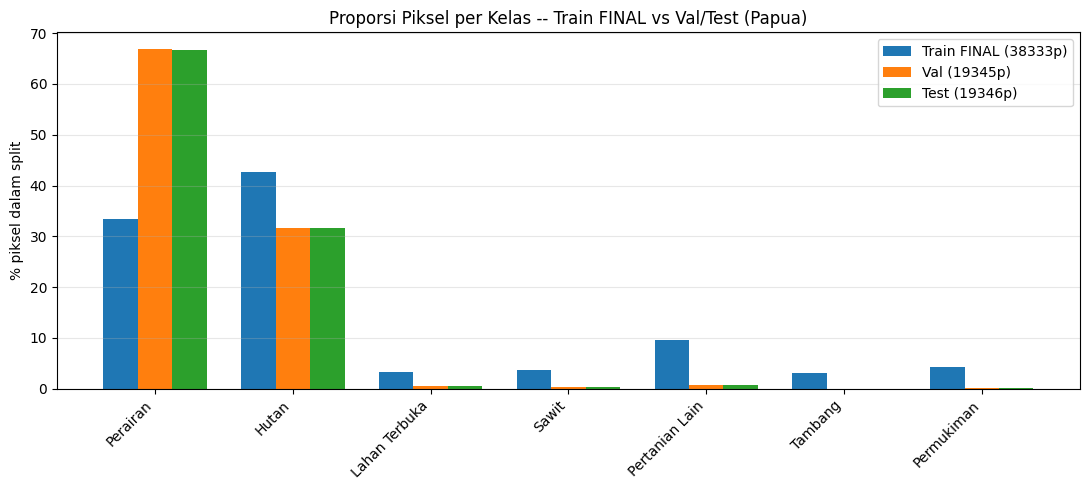

In [ ]:
# === EDA cepat: distribusi piksel -- TRAIN FINAL (papua+transfer+aug) vs Val/Test holdout ===
# Sanity-check sebelum training. Hasil di-cache ke BAHAN_DIR/optimize_cache/pixel_dist_cache.json
# sehingga run berikutnya (pakai GPU) langsung baca JSON, tidak scan ulang 77k+ patch dari Drive.
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm


def _count_pixels(files, max_workers=64):
    counts = {c: 0 for c in range(N_CLASSES)}
    if not files:
        return counts

    def _read_lab(f):
        return np.load(f)['lab']

    with ThreadPoolExecutor(max_workers=max_workers) as exe:
        for lab in tqdm(exe.map(_read_lab, files), total=len(files), desc='Counting pixels'):
            u, cnt = np.unique(lab, return_counts=True)
            for cls, n in zip(u.tolist(), cnt.tolist()):
                if 0 <= int(cls) < N_CLASSES:
                    counts[int(cls)] += int(n)
    return counts


# Cache pixel dist -- scan Drive lambat (~41 menit), hasil deterministik untuk dataset tetap
_dist_cache_path = BAHAN_DIR / 'optimize_cache' / 'pixel_dist_cache.json'
_dist_cache_path.parent.mkdir(parents=True, exist_ok=True)
_cache_key = (len(final_train_files), len(val_p), len(test_p))

_cached = None
if _dist_cache_path.exists():
    try:
        _c = json.loads(_dist_cache_path.read_text(encoding='utf-8'))
        if (_c.get('train_n'), _c.get('val_n'), _c.get('test_n')) == _cache_key:
            _cached = _c
            print(f'[cache] pixel_dist_cache.json dibaca '
                  f'(train={_c["train_n"]}, val={_c["val_n"]}, test={_c["test_n"]}) '
                  f'-- skip Counting pixels.')
    except Exception:
        _cached = None

if _cached:
    _train_dist = {int(k): v for k, v in _cached['train'].items()}
    _val_dist   = {int(k): v for k, v in _cached['val'].items()}
    _test_dist  = {int(k): v for k, v in _cached['test'].items()}
else:
    _train_dist = _count_pixels(final_train_files)
    _val_dist   = _count_pixels(val_p)
    _test_dist  = _count_pixels(test_p)
    _dist_cache_path.write_text(json.dumps({
        'train_n': _cache_key[0], 'val_n': _cache_key[1], 'test_n': _cache_key[2],
        'train': _train_dist, 'val': _val_dist, 'test': _test_dist,
    }), encoding='utf-8')
    print(f'[cache] pixel_dist_cache.json disimpan ke {_dist_cache_path}')

split_dist = {
    f'Train FINAL ({len(final_train_files)}p)': _train_dist,
    f'Val ({len(val_p)}p)':                     _val_dist,
    f'Test ({len(test_p)}p)':                   _test_dist,
}

print('Proporsi piksel per kelas -- Train FINAL (papua+transfer+aug) vs Val/Test holdout:')
print()
print(f"  {'Kelas':<16}" + ''.join(f'{name:>22}' for name in split_dist))
for c in range(N_CLASSES):
    row = f"  {CLASS_NAMES[c]:<16}"
    for d in split_dist.values():
        total = sum(d.values()) or 1
        row += f'{100 * d.get(c, 0) / total:5.1f}% ({d.get(c, 0):>13,})'.rjust(22)
    print(row)
print(f"  {'TOTAL piksel':<16}" + ''.join(f'{sum(d.values()):>22,}' for d in split_dist.values()))


In [ ]:
# === Worker tuning (dinamis: optimal di lab multi-core, minimal 4 di Colab) ===
import os
N_WORKERS = max(4, min(8, (os.cpu_count() or 2) - 1))
print(f"os.cpu_count()={os.cpu_count()} -> num_workers={N_WORKERS}; "
      "persistent_workers=True, pin_memory=True (di-set saat build DataLoader).")

os.cpu_count()=2 -> num_workers=4; persistent_workers=True, pin_memory=True (di-set saat build DataLoader).


## Bagian 15 — Build Model + Training (Attention U-Net (SCSE))

In [ ]:
# === Identitas model (HANYA cell ini yang beda antar-3 notebook training) ===
MODEL_KEY  = "model_1_attention_unet"
MODEL_ARCH = dict(architecture="unet_scse", encoder_name="resnet50")
MODEL_DIR  = MODELS_ROOT / MODEL_KEY
OUTPUT_DIR = MODEL_DIR / 'output'   # khusus GAMBAR (kurva, confusion matrix)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH  = MODEL_DIR / 'best_model.pt'      # per-model -> tak bentrok antar mesin
print('MODEL_KEY :', MODEL_KEY, '|', MODEL_ARCH)
print('MODEL_DIR :', MODEL_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

MODEL_KEY : model_1_attention_unet | {'architecture': 'unet_scse', 'encoder_name': 'resnet50'}
MODEL_DIR : /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet


In [ ]:
# === Build DataLoaders + model + loss ===
from forestwatch.model.architecture import build_unet, count_parameters
from forestwatch.model.losses import make_loss_fn

use_sampler = cfg['training'].get('use_weighted_sampler', True)
train_loader, val_loader, test_loader = build_dataloaders_from_files(
    final_train_files, val_p, test_p,
    batch_size=cfg['training']['batch_size'],
    num_workers=N_WORKERS,
    augment_p=cfg['training']['augmentation'],
    class_weights=class_weights if use_sampler else None,
    sampler_cache=SAMPLER_CACHE,  # = BAHAN_DIR/patch_sampler_weights_shared.json (cell bundling)
    # Semua ENV kini extract ke disk lokal (cell 5) -> final_train_files berisi path
    # lokal hasil ekstrak (termasuk train_rajaampat). keys=None -> compute_patch_sampler_weights
    # menurunkan key dari parts[-3:] tiap path, cocok dgn cache precomputed (papua/transfer/
    # aug/rajaampat). JANGAN pakai sampler_keys lama (dihitung sblm RA digabung -> beda panjang).
    sampler_keys=None,
    persistent_workers=True,
)
print(f"Train {len(train_loader.dataset)} | Val {len(val_loader.dataset)} | Test {len(test_loader.dataset)}")

model = build_unet(
    in_channels=cfg['model']['in_channels'], classes=cfg['model']['classes'],
    encoder_weights=cfg['model']['encoder_weights'], **MODEL_ARCH,
)
print(f"{MODEL_KEY}: {count_parameters(model):,} param trainable")

lc = cfg['training']['loss']
loss_fn = make_loss_fn(
    loss_type=lc['type'],
    class_weights=class_weights if cfg['training'].get('use_class_weights', True) else None,
    tversky_alpha=lc.get('tversky_alpha', 0.3), tversky_beta=lc.get('tversky_beta', 0.7),
    focal_gamma=lc.get('focal_gamma', 2.0),
)
print('Loss:', lc['type'])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train 38333 | Val 19345 | Test 19346


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model_1_attention_unet: 33,826,354 param trainable
Loss: focal_tversky


In [ ]:
# === Training (transfer-learning 2-tahap + resume + grad-clip) ===
# RE-RUNNABLE: jalankan ulang -> lanjut dari checkpoint per-model bila sesi mati.
import time
from forestwatch.training.trainer import TrainConfig, train

tcfg = TrainConfig(
    epochs=cfg['training']['epochs'], patience=cfg['training']['patience'],
    learning_rate=cfg['training']['learning_rate'], weight_decay=cfg['training']['weight_decay'],
    amp=cfg['training']['amp'], warmup_epochs=cfg['training'].get('warmup_epochs', 3),
    freeze_encoder_epochs=cfg['training'].get('freeze_encoder_epochs', 3),
    grad_clip=cfg['training'].get('grad_clip', 1.0), resume=cfg['training'].get('resume', True),
    seed=cfg['project']['seed'], ckpt_path=CKPT_PATH.as_posix(),
)
_t0 = time.time()
summary = train(model, train_loader, val_loader, loss_fn=loss_fn, cfg=tcfg)
train_minutes = round((time.time() - _t0) / 60, 1)
print(f"\nbest val mIoU = {summary['best_val_iou']:.4f} @ epoch {summary['best_epoch']} | {train_minutes} menit")
print("ckpt   :", summary['ckpt_path'])
print("resume :", summary['resume_path'], " (hapus file ini utk latih dari awal)")

2026-06-16 13:44:14 [INFO] forestwatch.training: Scheduler: LinearLR warmup 3 ep -> CosineAnnealingLR.
2026-06-16 13:44:14 [INFO] forestwatch.training: Encoder DIBEKUKAN epoch 1..3 (latih decoder dulu).
2026-06-16 13:44:14 [INFO] forestwatch.training: Mulai training: device=cpu, AMP=False, epochs=80 (mulai ep 1)


Epoch 01 [train]:   0%|          | 0/4791 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 01 [train]:   1%|          | 55/4791 [10:35<14:48:14, 11.25s/it]

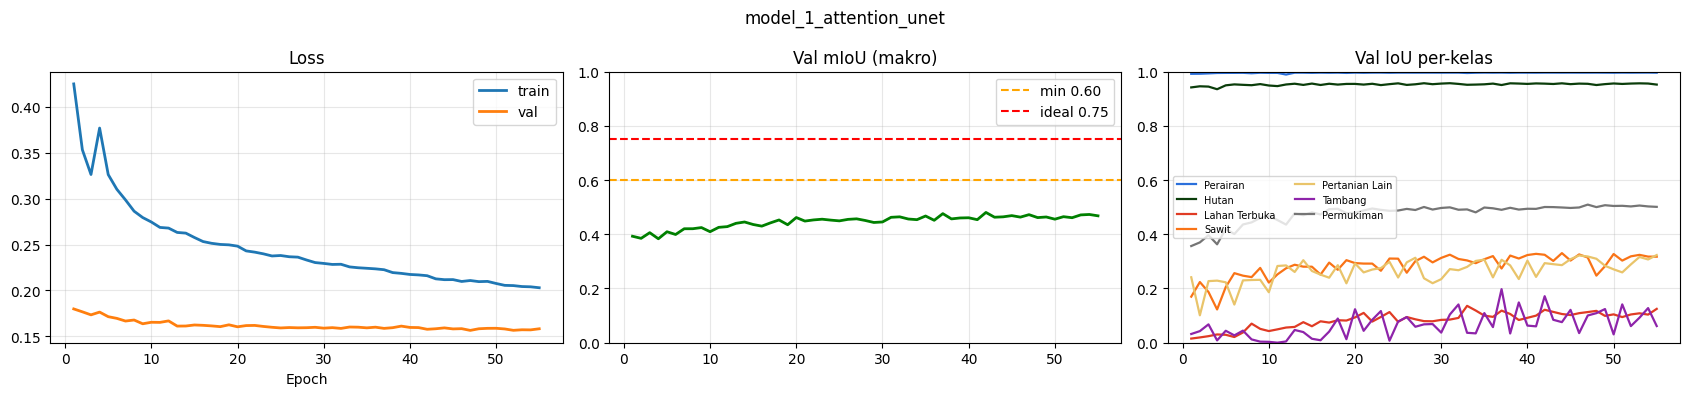

Disimpan: /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet/output/training_curve.png + training_history.json


In [2]:
# === Plot history -> MODEL_DIR ===
import matplotlib.pyplot as plt
from forestwatch.constants import CLASS_COLORS

hist = summary['history']; epochs = [h['epoch'] for h in hist]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(epochs, [h['train_loss'] for h in hist], label='train', lw=2)
axes[0].plot(epochs, [h['val_loss'] for h in hist], label='val', lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, [h['val_miou'] for h in hist], color='green', lw=2)
axes[1].axhline(0.60, color='orange', ls='--', label='min 0.60')
axes[1].axhline(0.75, color='red', ls='--', label='ideal 0.75')
axes[1].set_title('Val mIoU (makro)'); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)
if hist and 'val_iou_per_class' in hist[-1]:
    for c in range(N_CLASSES):
        ys = [h.get('val_iou_per_class', [float('nan')] * N_CLASSES)[c] for h in hist]
        axes[2].plot(epochs, ys, color=CLASS_COLORS[c], label=CLASS_NAMES[c], lw=1.6)
    axes[2].set_title('Val IoU per-kelas'); axes[2].set_ylim(0, 1)
    axes[2].legend(fontsize=7, ncol=2); axes[2].grid(alpha=0.3)
else:
    axes[2].plot(epochs, [h['lr'] for h in hist], color='purple'); axes[2].set_title('LR')
fig.suptitle(MODEL_KEY); fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curve.png', dpi=120, bbox_inches='tight'); plt.show()
save_json({'best_val_iou': summary.get('best_val_iou'), 'best_epoch': summary.get('best_epoch'),
           'history': hist}, MODEL_DIR / 'training_history.json')
print('Disimpan:', OUTPUT_DIR / 'training_curve.png', '+ training_history.json')

  patch 0/19346
  patch 2000/19346
  patch 4000/19346
  patch 6000/19346
  patch 8000/19346
  patch 10000/19346
  patch 12000/19346
  patch 14000/19346
  patch 16000/19346
  patch 18000/19346
OA=98.36% | mIoU=0.4985 | kappa=0.9638
  Perairan         IoU=0.9960  F1=0.9980
  Hutan            IoU=0.9552  F1=0.9771
  Lahan Terbuka    IoU=0.1143  F1=0.2052
  Sawit            IoU=0.4118  F1=0.5833
  Pertanian Lain   IoU=0.2740  F1=0.4301
  Tambang          IoU=0.1948  F1=0.3261
  Permukiman       IoU=0.5435  F1=0.7042


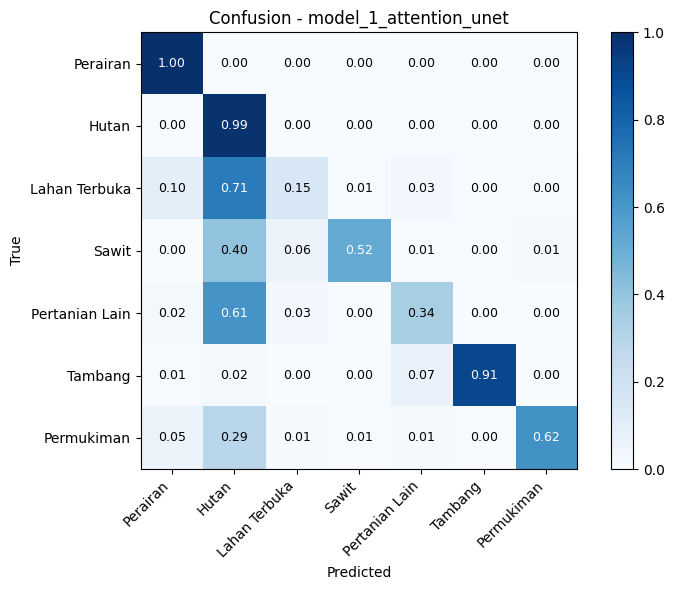

Disimpan: /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet/metrics.json + /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet/output/confusion_matrix.png


In [3]:
# === Evaluasi test (Papua holdout) -> metrics.json + confusion_matrix.png ===
# BARE-MINIMUM: loop manual baca .npz satu-satu (TANPA DataLoader/worker/pin_memory).
# Terbukti empiris RAM stabil ~1.7GB sepanjang 19rb+ patch; versi DataLoader bocor >30GB.
import numpy as np, torch, gc
import matplotlib.pyplot as plt
from forestwatch.training.metrics import compute_confusion_matrix, metric_summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load(CKPT_PATH, map_location='cpu'))
model = model.to(device).eval()

cm = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
with torch.no_grad():
    for i, fpath in enumerate(test_p):
        d = np.load(fpath)
        img = torch.from_numpy(d['img']).float().unsqueeze(0).to(device)
        pred = model(img).argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)
        cm += compute_confusion_matrix(pred, d['lab'], n_classes=N_CLASSES)
        del d, img, pred
        if i % 2000 == 0:
            gc.collect(); torch.cuda.empty_cache()
            print(f'  patch {i}/{len(test_p)}')

metrics = metric_summary(cm, class_names=CLASS_NAMES)
print(f"OA={metrics['overall_accuracy']*100:.2f}% | mIoU={metrics['mean_iou']:.4f} | kappa={metrics['kappa']:.4f}")
for row in metrics['per_class']:
    print(f"  {row['class']:<16} IoU={row['iou']:.4f}  F1={row['f1']:.4f}")
save_json(metrics, MODEL_DIR / 'metrics.json')

cm_np = np.array(metrics['confusion_matrix']); cm_norm = cm_np / cm_np.sum(axis=1, keepdims=True).clip(1)
fig, ax = plt.subplots(figsize=(8, 6)); im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if cm_norm[i, j] > 0.5 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'Confusion - {MODEL_KEY}')
fig.colorbar(im, ax=ax); fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight'); plt.show()
print('Disimpan:', MODEL_DIR / 'metrics.json', '+', OUTPUT_DIR / 'confusion_matrix.png')

In [4]:
# === Ekspor ONNX + tulis summary.json (dibaca notebook perbandingan) ===
# SELF-CONTAINED: ekspor inline (tak panggil export_to_onnx repo) -- kebal kode lama
# ke-cache. dynamo=False hindari exporter baru yg butuh paket onnxscript (tak ter-install).
import inspect, torch

model.eval()
_dev = next(model.parameters()).device
_ps = cfg['inference']['patch_size']
_dummy = torch.randn(1, cfg['model']['in_channels'], _ps, _ps, device=_dev)
_onnx_path = MODEL_DIR / 'model.onnx'
_kw = dict(input_names=['image'], output_names=['mask'], opset_version=13,
           dynamic_axes={'image': {0: 'batch'}, 'mask': {0: 'batch'}})
if 'dynamo' in inspect.signature(torch.onnx.export).parameters:
    _kw['dynamo'] = False
torch.onnx.export(model, _dummy, _onnx_path.as_posix(), **_kw)
print('ONNX disimpan:', _onnx_path)

save_json({
    'model_key': MODEL_KEY, **MODEL_ARCH,
    'best_val_iou': summary['best_val_iou'], 'best_epoch': summary['best_epoch'],
    'test_mean_iou': metrics['mean_iou'], 'test_overall_accuracy': metrics['overall_accuracy'],
    'test_kappa': metrics['kappa'], 'per_class': metrics['per_class'],
    'n_parameters': count_parameters(model), 'train_minutes': train_minutes,
    'epochs_cfg': cfg['training']['epochs'], 'batch_size': cfg['training']['batch_size'],
}, MODEL_DIR / 'summary.json')
print(f"OK {MODEL_KEY} SELESAI. Semua artefak di: {MODEL_DIR}")
print("   -> setelah ke-3 model selesai, jalankan compare_and_select_best_model.ipynb")

/tmp/ipykernel_1242/512046350.py:15: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, _dummy, _onnx_path.as_posix(), **_kw)


ONNX disimpan: /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet/model.onnx
OK model_1_attention_unet SELESAI. Semua artefak di: /content/drive/MyDrive/Satria Data 3.0/ForestWatch_Outputs/Model_Comparison/model_1_attention_unet
   -> setelah ke-3 model selesai, jalankan compare_and_select_best_model.ipynb
